## **Assignment 2: Generative Deep Learning - 708.088 (SS26)**
**Authored by:** Ozan Özdenizci, Institute of Machine Learning and Neural Computation, TU Graz

**Assignment issued on:** April 16th, 2026 09:00 AM\
**Assignment deadline:** May 14th, 2026 09:00 AM

# Training Generative Models via Denoising Score Matching

Training energy-based models and score networks using a denoising score matching loss, and generating samples via Langevin dynamics.


In [18]:
import os
import numpy as np
import matplotlib.pyplot as plt
import torch
import torchvision
from torchvision import transforms
from torch.utils.data import DataLoader
import torch.nn as nn
import torch.nn.functional as F

torch.manual_seed(42)
np.random.seed(42)

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Resize((10, 10)),   # downsample to 10x10
    transforms.Lambda(lambda x: 2. * x - 1.),  # represent data in [-1, 1]
    transforms.Lambda(lambda x: x.view(-1).float())
])

train_data = torchvision.datasets.MNIST(root='data/', train=True, transform=transform, download=True)
test_data = torchvision.datasets.MNIST(root='data/', train=False, transform=transform, download=True)

train_data, val_data = torch.utils.data.random_split(train_data, [55000, 5000])

training_loader = DataLoader(train_data, batch_size=128, shuffle=True)
val_loader = DataLoader(val_data, batch_size=128, shuffle=False)
test_loader = DataLoader(test_data, batch_size=128, shuffle=False)

## Part (a): Training an EBM with denoising score matching loss

In [19]:
class EnergyBasedDSM(nn.Module):
    def __init__(self, net, alpha, sigma, data_dim, T):
        super(EnergyBasedDSM, self).__init__()
        self.net = net
        self.data_dim = data_dim
        self.sigma = sigma
        self.T = T
        self.alpha = alpha

    def forward(self, x, reduction='mean'):
        # TODO: Energy-based denoising score matching loss
        #noise-corrupted input:
        x_tilde = x+ self.sigma*torch.randn_like(x)
        x_tilde.requires_grad_(True)#because we need gradient of log density afterwards
        #energy defined by network, make sure it's scalar value
        energy = self.net(x_tilde)
        energy = energy.reshape(x.size(0), -1).sum(dim=1)

        #estimating score with noisy x: s_theta(x_tilde) = -grad(E_theta(x_tilde))
        grad_x = torch.autograd.grad(outputs=energy.sum(), inputs=x_tilde, create_graph=True)[0]
        score_est = -grad_x  #(batch_size, data_dim)

        #True score for noisy data: -(x_tilde - x) / sigma^2
        true_score = (x - x_tilde) / (self.sigma ** 2)

        #DSM loss per sample: 0.5 * ||score_est - target_score||^2 *alpha
        ebm_dsm_loss = 1/2 * ((score_est - true_score) ** 2).sum(dim=1)*self.alpha  #(batch_size,)

        return ebm_dsm_loss.sum() if reduction == 'sum' else ebm_dsm_loss.mean()

    def sample_base(self, x_1):
        return 2. * torch.rand_like(x_1) - 1.

    def langevin_dynamics(self, x):
        # TODO: Langevin dynamics using the energy-based model
        #repeat for T langevin iterations
        for _ in range(self.T):
            x.requires_grad_(True) ## get batch of initial samples (batch_size, data_dim)
            # Compute energy as scalar value
            energy = self.net(x)
            energy = energy.reshape(x.size(0), -1).sum(dim=1)

            #Compute gradient
            grad_x = torch.autograd.grad(outputs=energy.sum(), inputs=x )[0]

            #update with langevin step: x = x - alpha/2 * grad(E + sqrt(alpha) * noise)
            x = x - 0.5 * self.alpha * grad_x + (self.alpha ** 0.5) * torch.randn_like(x)

            #detach computation graph after every iteration
            x = x.detach()
        return x

    def sample(self, batch_size=64):
        x = self.sample_base(torch.empty(batch_size, self.data_dim))
        x = self.langevin_dynamics(x)
        return torch.tanh(x)

In [ ]:
def evaluation(test_loader, model):
    model.eval()
    loss = 0.
    N = 0.
    for i, (test_batch, _) in enumerate(test_loader):
        loss_t = model.forward(test_batch, reduction='sum')
        loss = loss + loss_t.item()
        N = N + test_batch.shape[0]
    loss = loss / N
    return loss


def training(name, num_epochs, model, optimizer, training_loader, val_loader):
    val_losses = []

    for ep in range(num_epochs):
        model.train()
        for _, (batch, _) in enumerate(training_loader):
            # TODO: Main training steps and loss computation
            training_batch = batch.to(next(model.parameters()).device)
            #reset optimizer
            optimizer.zero_grad()
            #DSM loss and backprop
            loss = model(batch, reduction = "mean")
            loss.backward()

            #update params
            optimizer.step()

        val_loss = evaluation(val_loader, model)
        val_losses.append(val_loss)

        print(f'Epoch: {ep}, val loss={val_loss:.4f}')
        torch.save(model, name + '.model')

        # TODO: Generate and visualize some samples from the model.
        #cpu needed, because we use numpy
        if ep%10==0:
            samples = model.sample(batch_size=64).cpu().numpy()

            # Plot a few samples
            rows = 2
            cols = 3
            fig, ax = plt.subplots(rows, cols, figsize=(9, 6))
            for i in range(6):
                ax[i//cols][i%cols].imshow(samples[i].reshape(10, 10), cmap='gray')
                ax[i//cols][i%cols].axis('off')
            plt.show()

    return np.asarray(val_losses)

## Part (b): EBM initialization, hyperparameters and training

Epoch: 0, val loss=0.3511


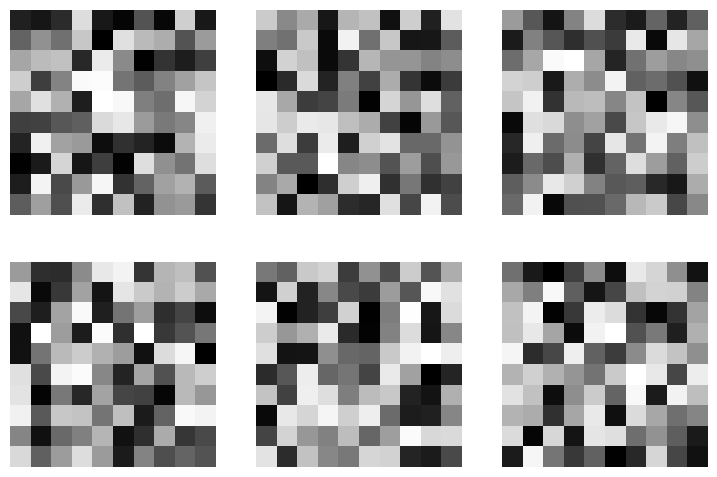

Epoch: 1, val loss=0.3540


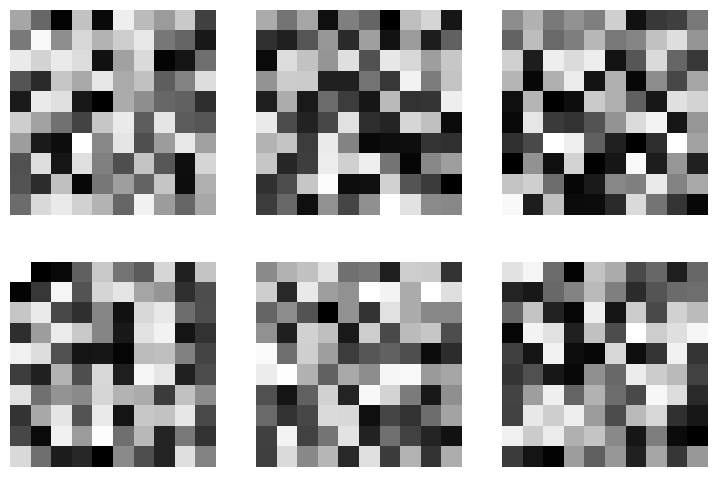

Epoch: 2, val loss=0.3621


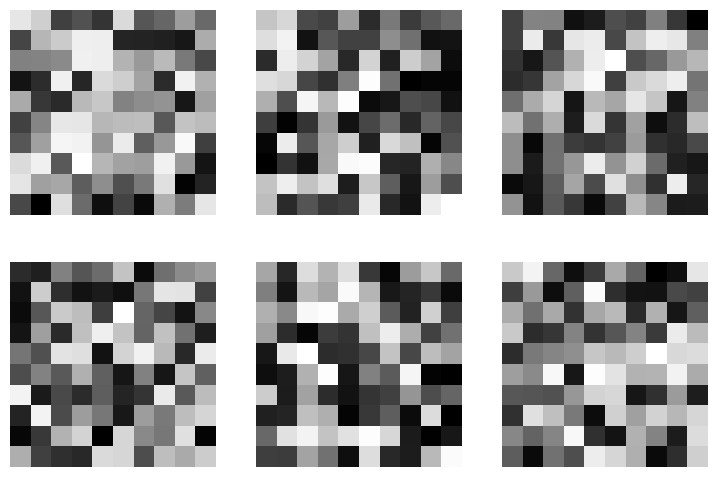

Epoch: 3, val loss=0.3627


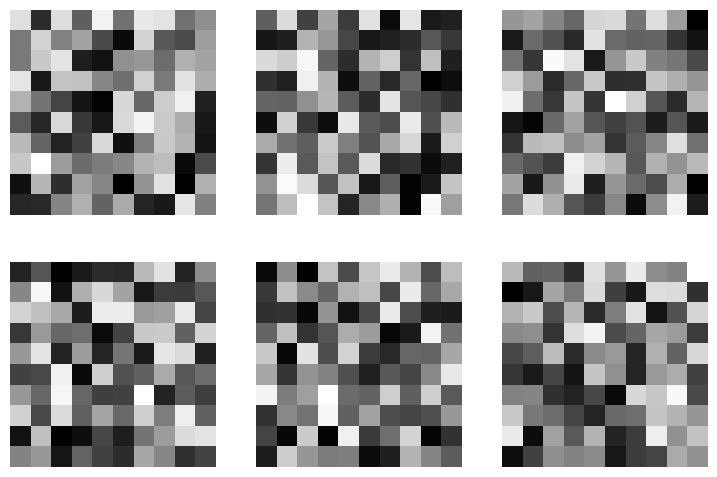

Epoch: 4, val loss=0.3495


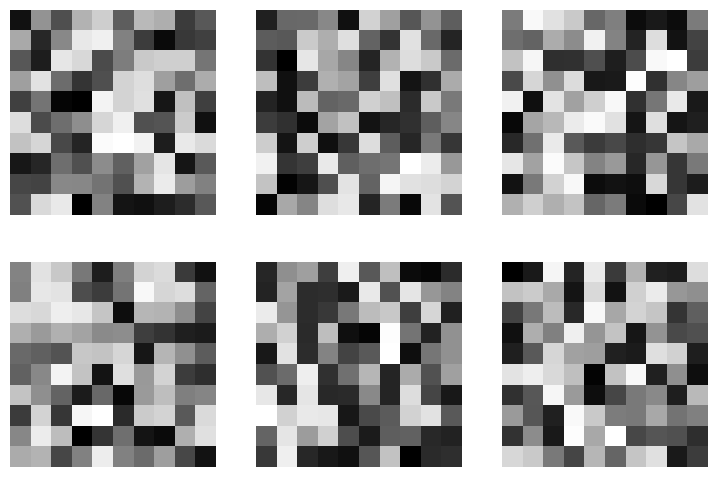

Epoch: 5, val loss=0.3512


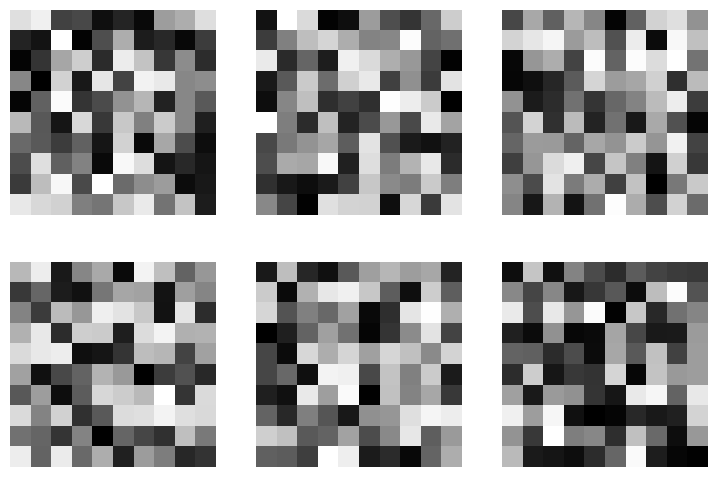

Epoch: 6, val loss=0.3455


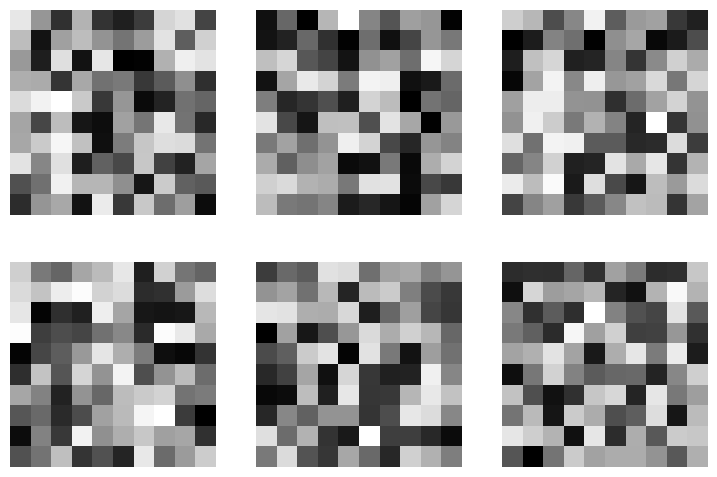

Epoch: 7, val loss=0.3593


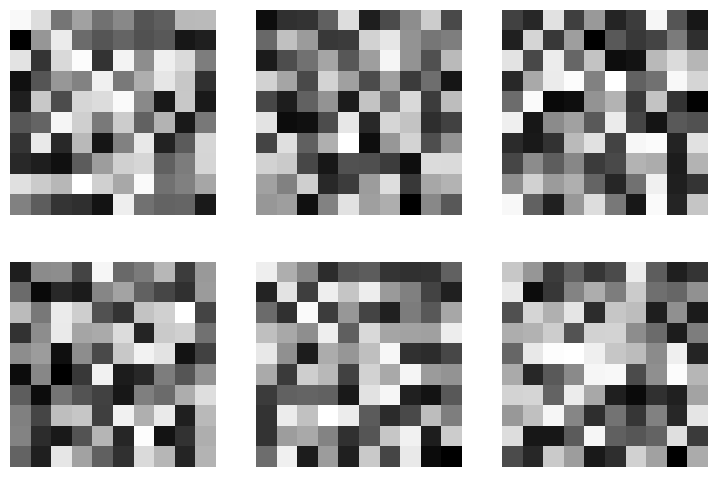

Epoch: 8, val loss=0.3429


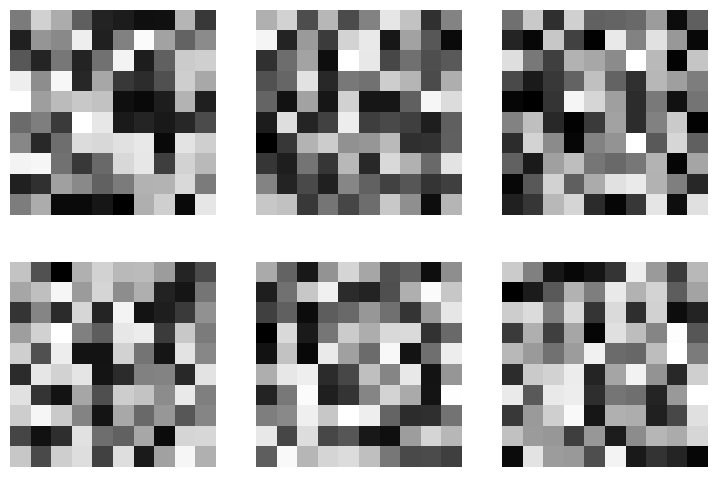

Epoch: 9, val loss=0.3518


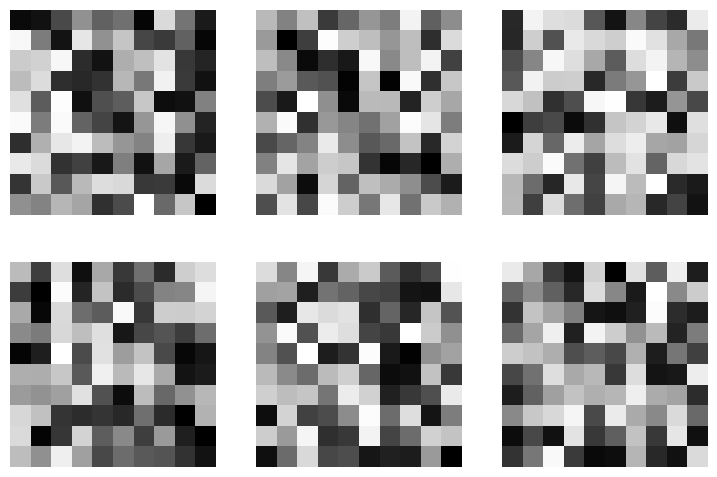

Epoch: 10, val loss=0.3476


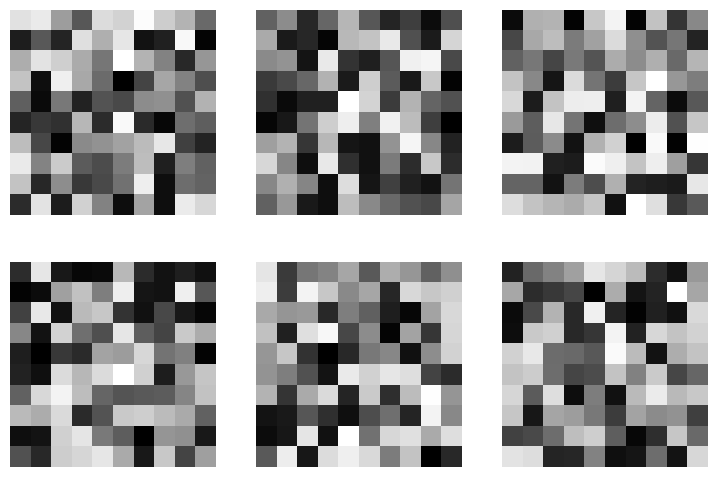

Epoch: 11, val loss=0.3410


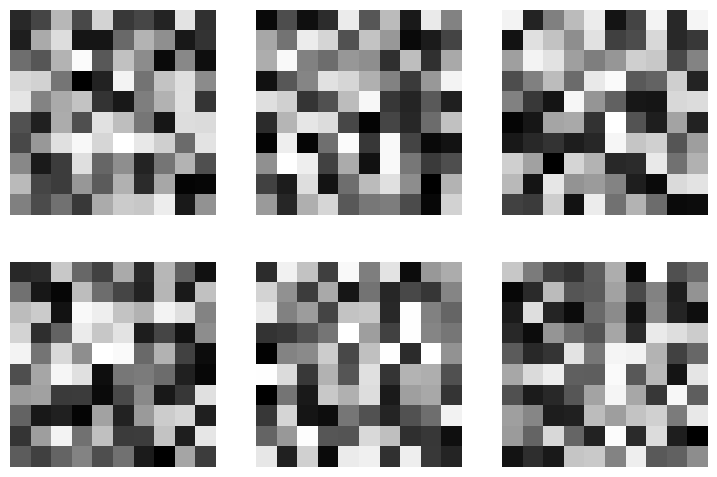

Epoch: 12, val loss=0.3428


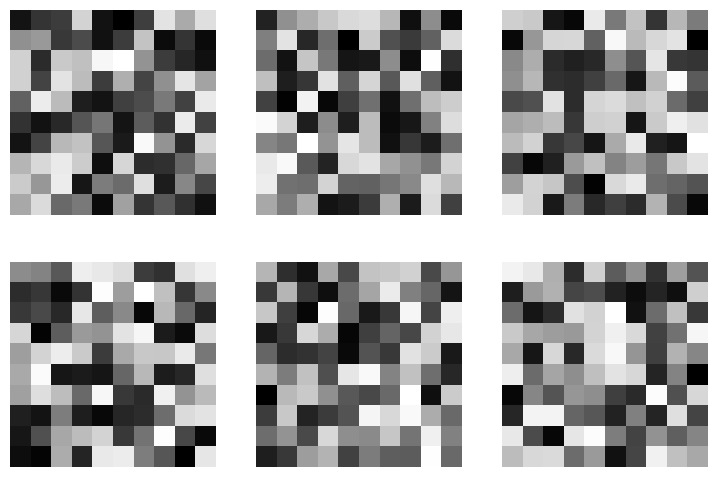

Epoch: 13, val loss=0.3363


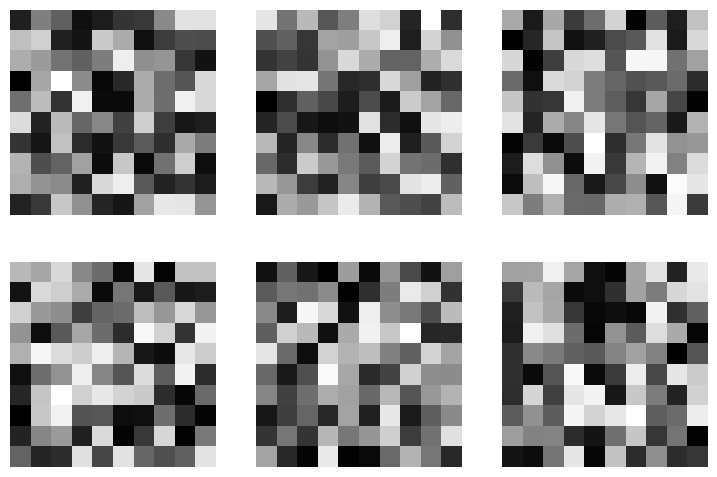

Epoch: 14, val loss=0.3287


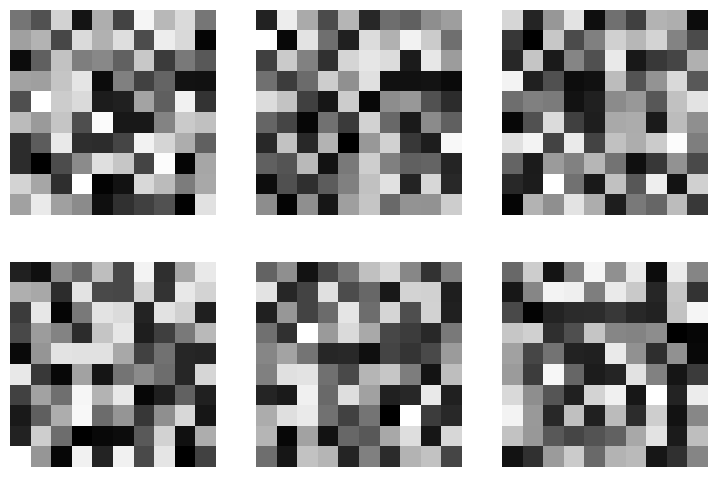

Epoch: 15, val loss=0.3401


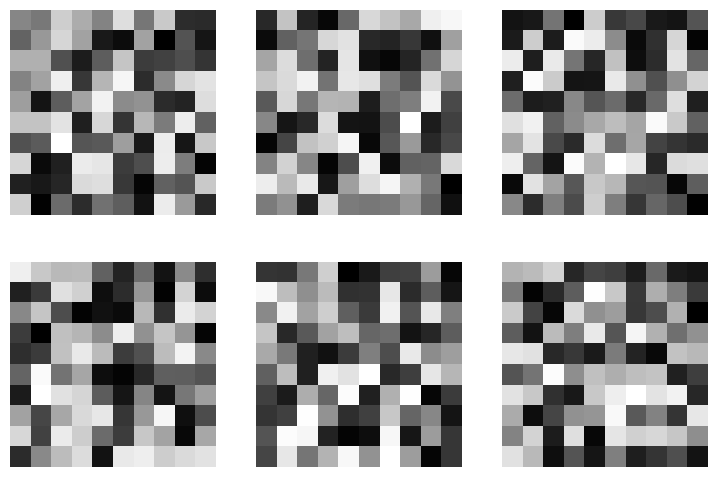

Epoch: 16, val loss=0.3449


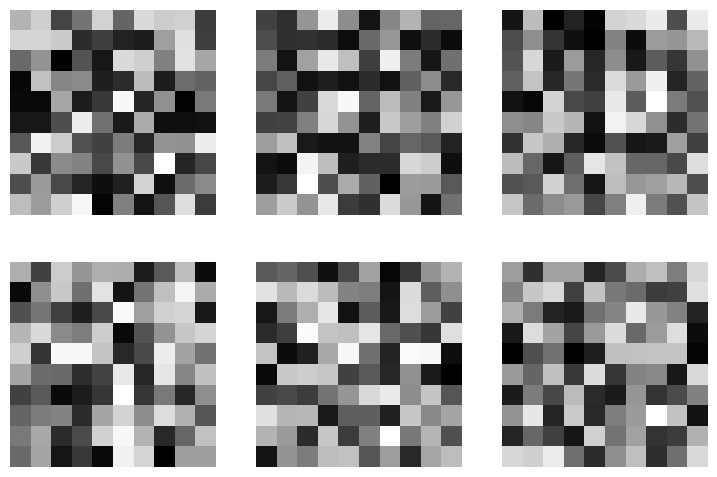

Epoch: 17, val loss=0.3561


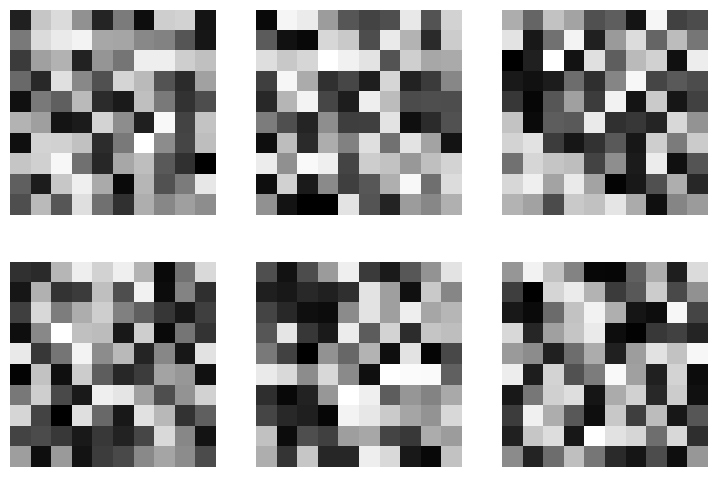

Epoch: 18, val loss=0.3377


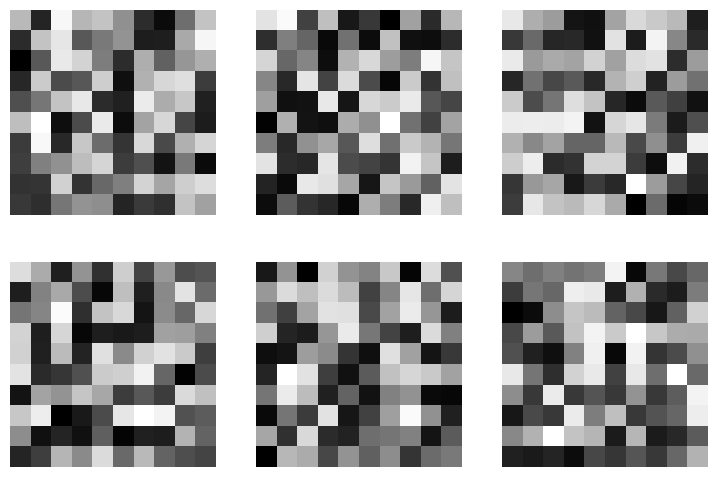

Epoch: 19, val loss=0.3380


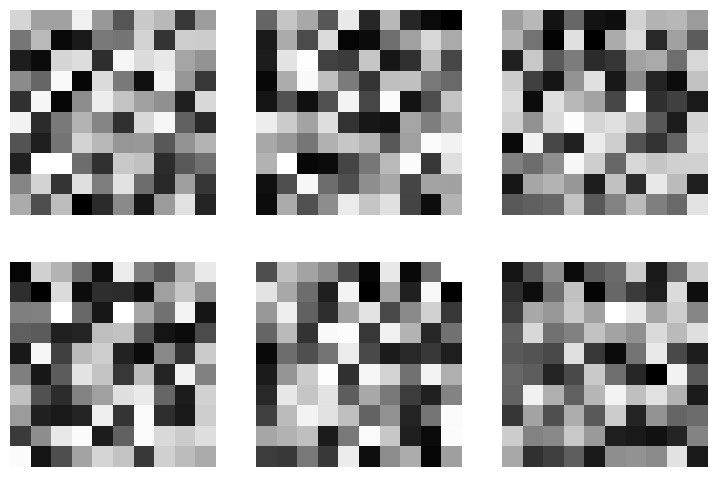

Epoch: 20, val loss=0.3310


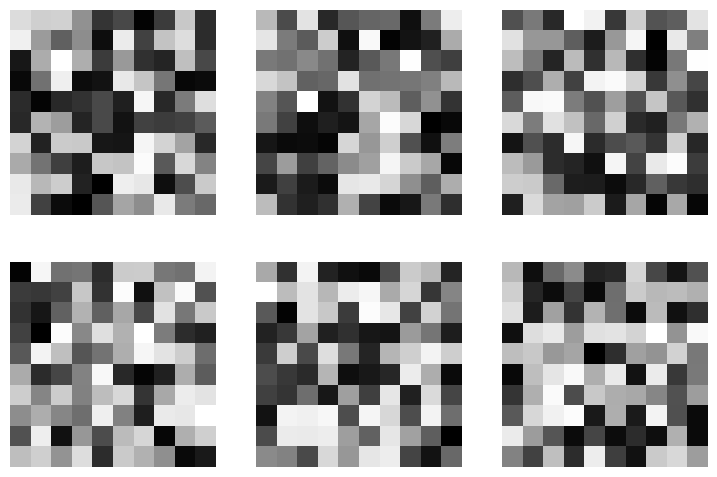

Epoch: 21, val loss=0.3316


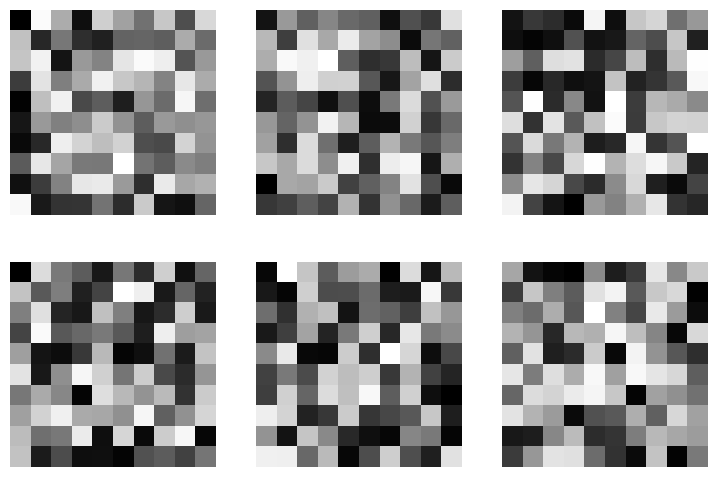

Epoch: 22, val loss=0.3263


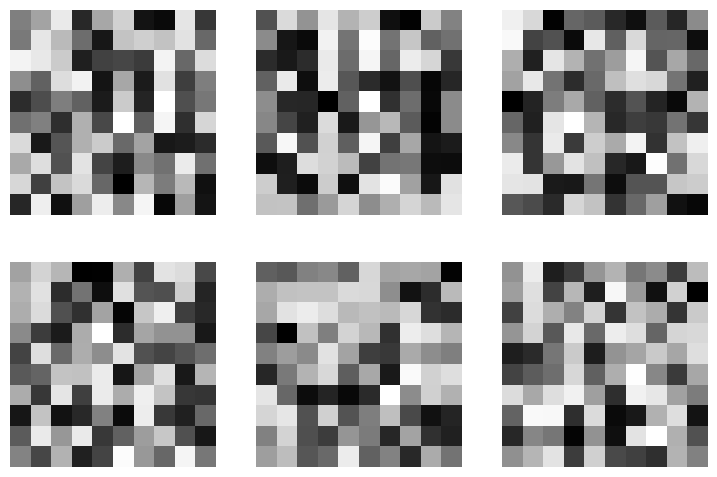

KeyboardInterrupt: 

In [32]:
data_dim = 100        # input data dimensionality
sigma = 0.3           # noise level for denoising score matching
alpha = 1e-2          # Langevin step size
T = 10               # Langevin steps
lr = 1e-2            # learning rate
num_epochs = 50      # maximum number of epochs

result_dir = 'results/'
if not(os.path.exists(result_dir)):
    os.mkdir(result_dir)
name = 'ebm-dsm'

# TODO: Energy network architecture
#define energy architecture
class EnergyNet(nn.Module):
    def __init__(self, data_dim=100, hidden_dim=256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(data_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1)  # scalar energy
        )

    def forward(self, x):
        return self.net(x).squeeze(-1)
energy_net = EnergyNet(data_dim=data_dim, hidden_dim=256)


ebm_dsm_model = EnergyBasedDSM(net=energy_net, alpha=alpha, sigma=sigma, T=T, data_dim=data_dim)

optimizer = torch.optim.Adam([p for p in ebm_dsm_model.parameters() if p.requires_grad == True], lr=lr)

val_losses = training(name=result_dir + name, num_epochs=num_epochs, model=ebm_dsm_model, optimizer=optimizer,
                      training_loader=training_loader, val_loader=val_loader)

In [ ]:
# TODO: Visualize the EBM model training process
plt.figure()
plt.plot(val_losses)
plt.xlabel("Epoch")
plt.ylabel("Validation DSM Loss")
plt.title("Validation Loss Curve")
plt.show()


# TODO: Visualize EBM model reconstructions versus test data samples
test_batch, _ = next(iter(test_loader))
test_batch = test_batch[:6].cpu().numpy()

samples = ebm_dsm_model.sample(batch_size=6).cpu().numpy()

fig, ax = plt.subplots(2, 6, figsize=(12, 4))
for i in range(6):
    ax[0, i].imshow(test_batch[i].reshape(10,10), cmap='gray')
    ax[0, i].set_title("Test")
    ax[0, i].axis('off')

    ax[1, i].imshow(samples[i].reshape(10,10), cmap='gray')
    ax[1, i].set_title("Generated")
    ax[1, i].axis('off')

plt.show()


# TODO: Evaluate the loss on the test set
test_loss = evaluation(test_loader, ebm_dsm_model)
print("Test DSM loss:", test_loss)


# TODO: Generate and visualize samples from the final model.
samples = ebm_dsm_model.sample(batch_size=64).cpu().numpy()

fig, ax = plt.subplots(8, 8, figsize=(8, 8))
for i in range(64):
    ax[i//8, i%8].imshow(samples[i].reshape(10,10), cmap='gray')
    ax[i//8, i%8].axis('off')
plt.show()


## Part (c): Training a SBM with denoising score matching loss

In [ ]:
class ScoreBasedDSM(nn.Module):
    def __init__(self, net, alpha, sigma, data_dim, T):
        super(ScoreBasedDSM, self).__init__()
        self.net = net
        self.data_dim = data_dim
        self.sigma = sigma
        self.T = T
        self.alpha = alpha

    def forward(self, x, reduction='mean'):
        # TODO: Score-based denoising score matching loss
        # ...
        # ...
        return sbm_dsm_loss.sum() if reduction == 'sum' else sbm_dsm_loss.mean()

    def sample_base(self, x_1):
        return 2. * torch.rand_like(x_1) - 1.

    def langevin_dynamics(self, x):
        # TODO: Langevin dynamics using the score-based model
        # ...
        # ...
        return x

    def sample(self, batch_size=64):
        x = self.sample_base(torch.empty(batch_size, self.data_dim))
        x = self.langevin_dynamics(x)
        return torch.tanh(x)

## Part (d): SBM initialization, hyperparameters and training

In [ ]:
# SBM training hyperparameters
data_dim = 100        # input data dimensionality
sigma = 0.3           # noise level for denoising score matching
alpha = ...           # Langevin step size
T = ...               # Langevin steps
lr = 1e-3             # learning rate
num_epochs = 200      # maximum number of epochs

result_dir = 'results/'
if not(os.path.exists(result_dir)):
    os.mkdir(result_dir)
name = 'sbm-dsm'

# TODO: Score estimator network architecture
# score_net = ...
# ...
# ...

sbm_dsm_model = ScoreBasedDSM(net=score_net, alpha=alpha, sigma=sigma, T=T, data_dim=data_dim)

optimizer = torch.optim.Adam([p for p in sbm_dsm_model.parameters() if p.requires_grad == True], lr=lr)

val_losses = training(name=result_dir + name, num_epochs=num_epochs, model=sbm_dsm_model, optimizer=optimizer,
                      training_loader=training_loader, val_loader=val_loader)

In [ ]:
# TODO: Visualize the SBM model training process
# ...
# ...

# TODO: Visualize SBM model reconstructions versus test data samples
# ...
# ...

# TODO: Evaluate the loss on the test set
# ...
# ...

# TODO: Generate and visualize samples from the final model.
# ...
# ...
